In [1]:
import torchvision
import torch
import torch.nn as nn
import numpy as np
from utils import *

torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
import matplotlib.pyplot as plt
device = torch.device('cuda')

ImportError: DLL load failed: The specified procedure could not be found.

In [ ]:
class Block_1(nn.Module):
    def __init__(self):
        super(Block_1, self).__init__()
        rennet18 = torchvision.models.resnet18(pretrained=True)
        layers_rennet18 = list(rennet18.children())[:6]
        self.backbone_layer = nn.Sequential(*layers_rennet18)

        num_channels = 128
        self.conv_up_1 = nn.ConvTranspose2d(in_channels=num_channels, out_channels=num_channels // 2, kernel_size=2,
                                            stride=2)
        self.bn_up_1 = nn.BatchNorm2d(num_channels // 2)

        self.conv_up_2 = nn.ConvTranspose2d(in_channels=num_channels // 2, out_channels=num_channels // 4,
                                            kernel_size=2, stride=2)
        self.bn_up_2 = nn.BatchNorm2d(num_channels // 4)

        self.conv_up_3 = nn.ConvTranspose2d(in_channels=num_channels // 4, out_channels=1, kernel_size=2, stride=2)

        self.relu = nn.ReLU()

        self.dropout = nn.Dropout2d(0.5)
        self.sigmoid = nn.Sigmoid()
        self.tahn = nn.Tanh()

    def forward(self, x):
        x = self.backbone_layer(x)
        x = self.relu(self.bn_up_1(self.dropout(self.conv_up_1(x))))
        x = self.relu(self.bn_up_2(self.dropout(self.conv_up_2(x))))
        x = self.sigmoid(self.conv_up_3(x))
        return x


class Block_2(nn.Module):
    def __init__(self):
        super(Block_2, self).__init__()

    def forward(self, x):
        return x

class Block_out(nn.Module):
    def __init__(self):
        super(Block_out, self).__init__()
        self.conv_1 = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, stride=2, padding=1)
        self.conv_2 = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, stride=2, padding=1)
        self.conv_3 = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, stride=2, padding=1)
        self.conv_4 = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, stride=2, padding=1)

        self.fc_out = nn.Linear(in_features=14*14, out_features=32)
        self.bn = nn.BatchNorm2d(1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.tahn = nn.Tanh()

    def forward(self, x):
        batch_size = x.shape[0]
        x = self.relu(self.bn(self.conv_1(x)))
        x = self.relu(self.bn(self.conv_2(x)))
        x = self.relu(self.bn(self.conv_3(x)))
        x = self.relu(self.bn(self.conv_4(x)))
        x = x.reshape(batch_size, -1)
        x = self.fc_out(x)
        x = self.tahn(x)
        return x

class PoseNet(nn.Module):

    def __init__(self):
        super(PoseNet, self).__init__()
        self.block_1 = Block_1()
        self.block_out = Block_out()

    def forward(self, input):
        out_block_1 = self.block_1(input)

        coordinates = self.block_out(out_block_1)

        return out_block_1, coordinates

In [2]:
model = PoseNet().to(device)
criterion = nn.BCELoss()

batch_size = 2
dataset = MPII_dataset()
dataloader_train = DataLoader(dataset, shuffle=True, batch_size=batch_size)

current_batch = next(iter(dataloader_train))

image, coordinates_real, visibility_array_batch, height_batch, width_batch, center_batch = current_batch
image = image.to(device)

joints_canvas = generate_joints_heatmap(image, height_batch, width_batch, visibility_array_batch, coordinates_real).to(device)

output, _ = model(image)
loss = criterion(output, joints_canvas)
print(loss)

NameError: name 'PoseNet' is not defined

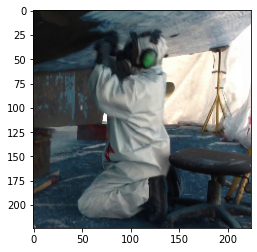

In [11]:
current_image = get_np_image_from_tensor(image[0])
plt.imshow(current_image)

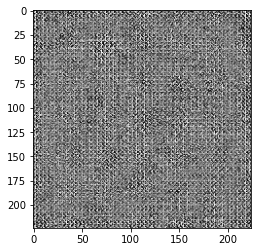

In [9]:
plt.subplots(2, 1)
plt.imshow(output.squeeze(1).detach().cpu().numpy()[0], cmap='gray')

In [11]:
heatmap_real = output.squeeze(1).detach().cpu().numpy()[0]
heatmap_pred = heatmap_real

[]

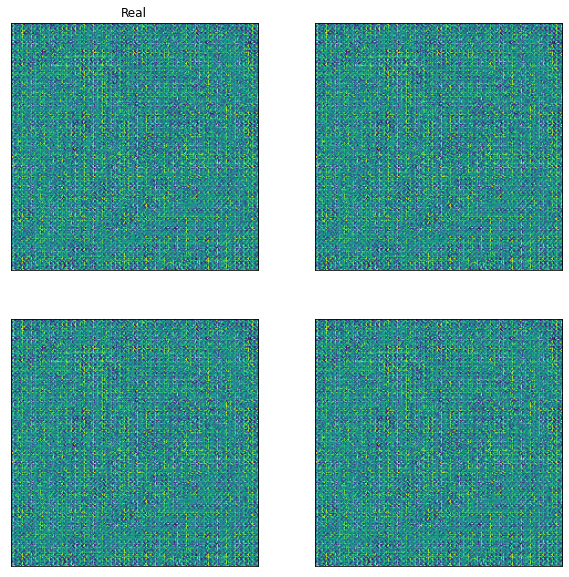

In [19]:
fig = plt.figure(figsize=(10, 10))
ax1 = fig.add_subplot(2,2,1)
ax1.imshow(heatmap_real)
ax1.set_title('Ground Truth')

ax2 = fig.add_subplot(2,2,2)
ax2.imshow(heatmap_pred)
ax1.set_title('Predicted Truth')

ax3 = fig.add_subplot(2,2,3)
ax3.imshow(heatmap_real)

ax4 = fig.add_subplot(2,2,4)
ax4.imshow(heatmap_pred)

ax1.set_xticks([])
ax1.set_yticks([])
ax2.set_xticks([])
ax2.set_yticks([])
ax3.set_xticks([])
ax3.set_yticks([])
ax4.set_xticks([])
ax4.set_yticks([])

In [20]:
model = torch.hub.load('pytorch/vision:v0.6.0', 'fcn_resnet101', pretrained=True)

Downloading: "https://github.com/pytorch/vision/archive/v0.6.0.zip" to C:\Users\abhi/.cache\torch\hub\v0.6.0.zip
Downloading: "https://download.pytorch.org/models/resnet101-5d3b4d8f.pth" to C:\Users\abhi/.cache\torch\hub\checkpoints\resnet101-5d3b4d8f.pth


Downloading: "https://download.pytorch.org/models/fcn_resnet101_coco-7ecb50ca.pth" to C:\Users\abhi/.cache\torch\hub\checkpoints\fcn_resnet101_coco-7ecb50ca.pth


In [21]:
model

FCN(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequenti

In [66]:
from scipy.ndimage import gaussian_filter

def apply_sigmoid(image):
    return 1 / (1 + np.exp(-image))

def normalize(image, min_value=0, max_value=1):
    return (image - min_value) / (max_value - min_value)

def generate_keypoint_heatmap(image, height_batch, width_batch, visibility_array_batch, coordinates_real, sigma=5):
    height = int(height_batch[0])
    width = int(width_batch[0])
    batch_size = image.shape[0]
    num_joints = visibility_array_batch.shape[1]
    heatmap_stack = np.zeros((batch_size, num_joints, height, width)).astype(np.float32)
    
    for image_index in range(batch_size):
        visibility_array = visibility_array_batch[image_index]
        current_coordinates = coordinates_real[image_index]

        joints_X_real, joints_Y_real = separate_X_Y(current_coordinates*height)
        joints_X_real = np.array(np.where(visibility_array>0, joints_X_real, -1))
        joints_Y_real = np.array(np.where(visibility_array>0, joints_Y_real, -1))

        for joint_index in range(num_joints):
            current_Y = int(joints_Y_real[joint_index])
            current_X = int(joints_X_real[joint_index])

            if not (current_X >= height or current_X < 0 or current_Y >= width or current_Y < 0):
                heatmap_stack[image_index, joint_index, current_Y, current_X] = 1
                heatmap_stack[image_index, joint_index] = gaussian_filter(heatmap_stack[image_index, joint_index], sigma=sigma)
    heatmap_stack = torch.tensor(heatmap_stack)
    return heatmap_stack



heatmap_stack = generate_keypoint_heatmap(image, height_batch, width_batch, visibility_array_batch, coordinates_real)

# heatmap_image_1 = heatmap_stack[0]

# plt.figure(figsize=(10, 10))
# plt.imshow(heatmap_image_1[0], cmap='gray')
# plt.show()

torch.float32

In [50]:
np.where(heatmap_image_1[1] > 0)

(array([128, 128, 128, ..., 168, 168, 168], dtype=int64),
 array([ 70,  71,  72, ..., 108, 109, 110], dtype=int64))

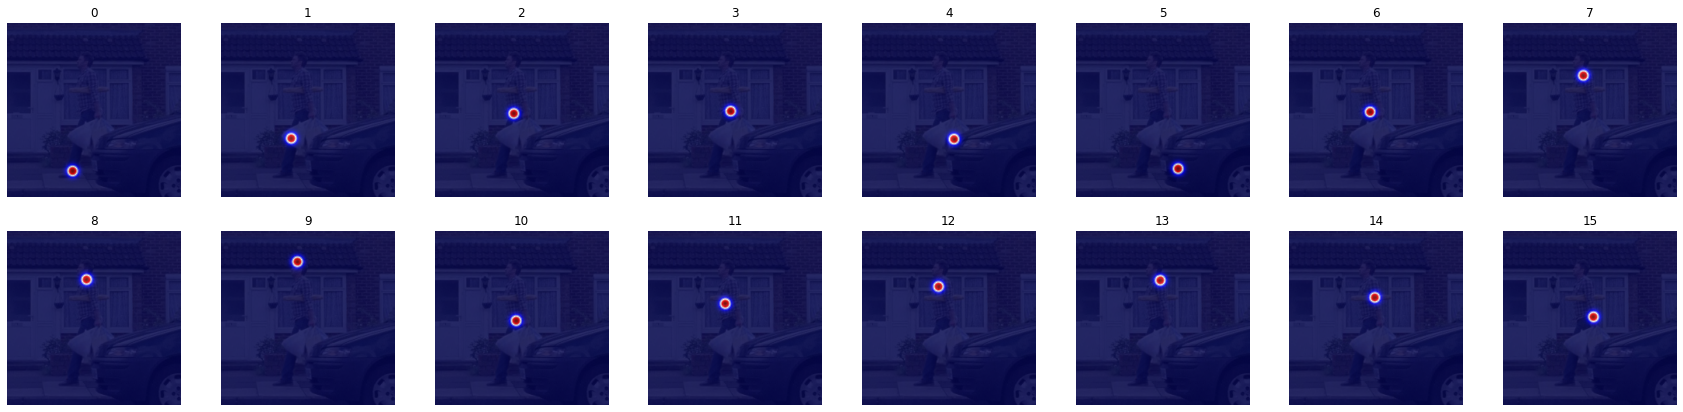

In [88]:
def visualize_keypoint_heatmaps(keypoints_tensor, image_tensor):
    image_tensor = image_tensor.detach().cpu().permute(0, 2, 3, 1).numpy()
    keypoints_tensor = keypoints_tensor.detach().cpu().numpy()
    num_keypoints = keypoints_tensor.shape[1]
    
    rows = int(np.ceil(num_keypoints/2))
    plt.figure(figsize=(30, 30))
    for index in range(num_keypoints):
        plt.subplot(rows, rows, index + 1)
        plt.axis('off')
        plt.imshow(image_tensor[0])
        plt.imshow(keypoints_tensor[0][index], cmap='seismic', alpha=0.8)
        plt.title(index)
    plt.show()

visualize_keypoint_heatmaps(heatmap_stack, image)
    

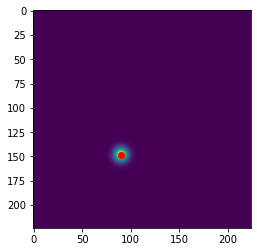

In [113]:
plt.imshow(heatmap_stack[0][1])
plt.scatter(max_index_col, max_index_row, c='r')

In [93]:
heatmap_stack[0][0]

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [120]:
def get_max_value_heatmap(heatmap_stack):
    batch_size = heatmap_stack.shape[0]
    num_keypoints = heatmap_stack.shape[1]
    
    keypoints_batch = np.zeros((batch_size, num_keypoints*2))
    
    
    for batch_index in range(batch_size):
        filter_index = 0
        for keypoint_index in range(0, num_keypoints*2, 2):
            keypoints_batch[batch_index, keypoint_index] = np.argmax(heatmap_stack[batch_index][filter_index], axis=1).max().item()
            keypoints_batch[batch_index, keypoint_index+1] = np.argmax(heatmap_stack[batch_index][filter_index], axis=0).max().item()
            filter_index += 1
    
    return keypoints_batch

keypoints_batch = get_max_value_heatmap(heatmap_stack)
print(keypoints_batch)
# max_index_row = np.argmax(heatmap_stack[0][1], axis=0).max().item()
# max_index_col = np.argmax(heatmap_stack[0][1], axis=1).max().item()
# print(max_index_row)
# print(max_index_col)

[[ 84. 190.  90. 148. 101. 116. 106. 113. 118. 149. 131. 187. 104. 114.
  103.  67.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
    0.   0.   0.   0.]
 [ 94.  82. 129.  25.  81. 223.  35. 178.  57. 100. 107. 101. 117. 160.
  143. 192.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
    0.   0.   0.   0.]]


In [102]:
print(max_index_row.max())

tensor(84)


In [104]:
print(max_index_col.max())

tensor(190)


In [126]:
coordinates_real*224

tensor([[  84.0000,  190.0225,   90.9213,  148.4944,  101.9326,  116.0899,
          106.0225,  113.2584,  118.2921,  149.1236,  131.8202,  187.8202,
          104.1348,  114.8315,  103.5056,   67.6404,  102.6813,   62.7859,
           98.6670,   39.1467,  104.1348,  115.4607,   99.1011,   93.1236,
           98.1573,   71.1011,  108.8539,   63.8652,  110.4270,   85.8876,
          116.0899,  110.4270],
        [-224.2018, -223.9628, -224.2018, -223.9628,   80.0646,  222.5223,
           88.4550,  218.2008, -224.2018, -223.9628, -224.2018, -223.9628,
           84.3869,  220.3615,   82.6071,  101.1590,   94.4084,   82.0350,
          129.0306,   25.9293,   81.5901,  221.8021,   35.8239,  178.5866,
           57.4357,  100.4387,  107.5243,  101.8792,  117.9488,  160.9403,
          143.6287,  192.2715]])

In [124]:
keypoints_batch.shape

(2, 32)

In [125]:
coordinates_real.shape

torch.Size([2, 32])

In [56]:
import torch

def get_max_value_heatmap(heatmap_stack):
    batch_size = heatmap_stack.shape[0]
    num_keypoints = heatmap_stack.shape[1]
    
    keypoints_batch = np.zeros((batch_size, num_keypoints*2))
    
    for batch_index in range(batch_size):
        filter_index = 0
        for keypoint_index in range(0, num_keypoints, 2):
            row, col = torch.where(y==torch.max(y))
            keypoints_batch[batch_index, keypoint_index] = row
            keypoints_batch[batch_index, keypoint_index+1] = col
            filter_index += 1
    
    return keypoints_batch

x = torch.tensor([[0, 2, 5, 2],
                 [2, 7, 0, 2321],
                 [1, 5, 6, 1000]], dtype=torch.float32)
x = x.unsqueeze(0).unsqueeze(0)
# print(x.shape)
print(get_max_value_heatmap(x))

[[1. 2.]]


In [45]:
y = x[0][0]
y

tensor([[0.0000e+00, 2.0000e+00, 5.0000e+00, 2.0000e+00],
        [2.0000e+00, 7.0000e+00, 2.0000e+03, 2.0000e+00],
        [1.0000e+00, 5.0000e+00, 6.0000e+00, 1.0000e+03]])

In [46]:
torch.max(y)

tensor(2000.)

In [48]:
a, b = torch.where(y==torch.max(y))

In [49]:
a

tensor([1])

In [1]:
from prettytable import PrettyTable

ModuleNotFoundError: No module named 'prettytable'